## Introduction

This notebook shows training of the ResNet model - First CNN appraoch.

## Setup

In [38]:
import os
import json
from datetime import datetime, timezone
import boto3
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from skin_lesion_project.processing.image_processing import training_data_transforms, test_val_transforms

from skin_lesion_project.datasets.dataloader import create_dataloaders
from skin_lesion_project.models.resnet import get_resnet50
from skin_lesion_project.training.train import train

In [2]:
# !/home/shadeform/miniconda/envs/skin-lesion-notebooks/bin/python -m pip uninstall torch torchvision torchaudio -y
# !/home/shadeform/miniconda/envs/skin-lesion-notebooks/bin/python -m pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --force-reinstall --no-cache-dir

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

NUM_CLASSES = 8
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

Device : cuda
GPU : NVIDIA RTX PRO 6000 Blackwell Server Edition


In [4]:
DEVICE

device(type='cuda')

In [5]:
!/home/shadeform/miniconda/envs/skin-lesion-notebooks/bin/python -m pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --force-reinstall -v

Using pip 26.1.2 from /home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/pip (python 3.10)
Looking in indexes: https://download.pytorch.org/whl/nightly/cu128, https://pypi.org/simple
  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/50/c0/68a84105e1fcb8970144b388ff3d3e5dc15a3be28c1e247841f7d7247e41/torch-2.13.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata
  Using cached torch-2.13.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Obtaining dependency information for torchvision from https://files.pythonhosted.org/packages/46/22/2f7ff1997d793e45d85fafa8374ee25348b7dae9ac521ba8751d7e1c75d5/torchvision-0.28.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata
  Using cached torchvision-0.28.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Obtaining dependency information for torchaudio from https://files.pythonhosted.org/packages/66/dc/5757ed7d8d11a6c14336bcb54e63980979f00005555fec80fb4aa4de5eff/torch

## Data Loaders

In [6]:
train_loader, val_loader, class_weights = create_dataloaders(
    train_transform=training_data_transforms(),
    val_transform=test_val_transforms(),
    train_image_dir="/home/shadeform/data/train",
    train_label_file="/home/shadeform/data/labels/mappings.pkl",
    val_image_dir="/home/shadeform/data/test",
    val_label_file="/home/shadeform/data/labels/mappings_test.pkl",
    batch_size=32,
)

Training Images   : 30931
Validation Images : 8238
Batch Size        : 32
Workers           : 16


## Images

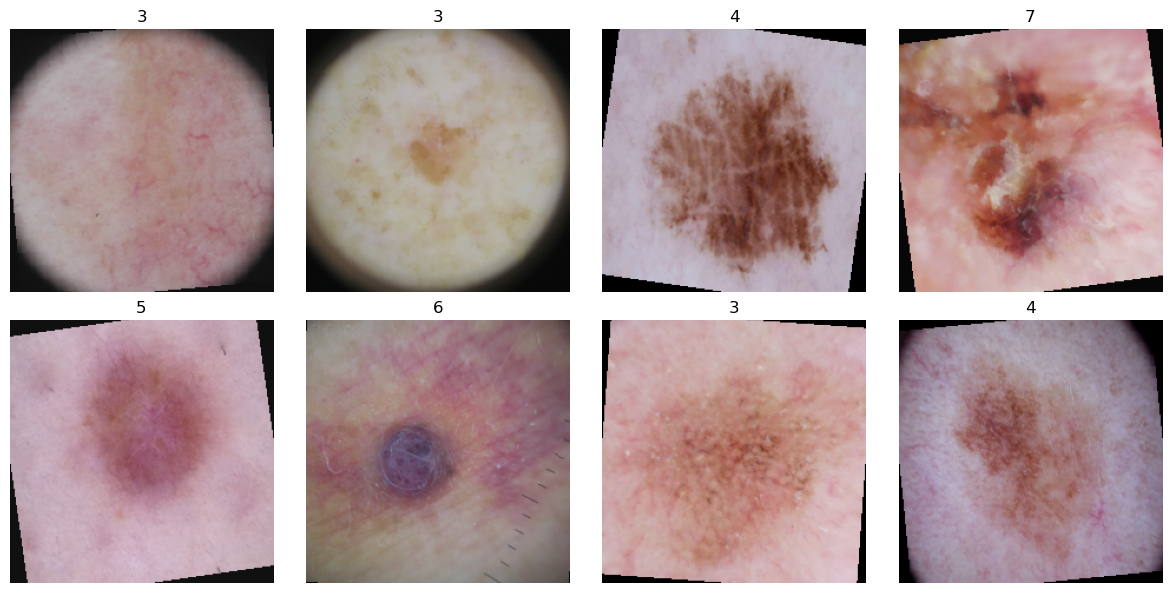

In [7]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2,4, figsize=(12,6))
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu()
    image = image * std + mean
    image = image.clamp(0,1)
    ax.imshow(image.permute(1,2,0))
    ax.set_title(labels[i].item())
    ax.axis("off")
plt.tight_layout()
plt.show()

## ResNet Model

In [8]:
model = get_resnet50(num_classes=8, pretrained=True)
model.freeze_backbone()
model.to(DEVICE)
model.summary()

Model            : ResNet-50
Output Classes   : 8
Feature Dimension: 2048
Trainable Params : 16,392


## Model Training

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)

EPOCHS_FROZEN = 30
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FROZEN)

history_frozen = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_FROZEN,
    checkpoint_path="checkpoints/resnet50_classifier.pt",
    early_stopping_patience=7,
)

Epoch 1/30: 100%|██████████| 967/967 [00:21<00:00, 45.49it/s, loss=1.1457]


Best model saved.
Epoch 1/30
Train Loss : 1.3001829326906267
Val Loss   : 2.6083871076685274
Train Acc  : 0.24839158126151756
Val Acc    : 0.029497450837581936
Precision  : 0.03222853713305869
Recall     : 0.25358599733599735
Macro F1   : 0.030846524226538875


Epoch 2/30: 100%|██████████| 967/967 [00:21<00:00, 45.78it/s, loss=1.0574]


Best model saved.
Epoch 2/30
Train Loss : 1.019337071043872
Val Loss   : 2.437951046160397
Train Acc  : 0.30955998836119103
Val Acc    : 0.042728817674192766
Precision  : 0.1684433916742619
Recall     : 0.27622262764897615
Macro F1   : 0.04768046140379202


Epoch 3/30: 100%|██████████| 967/967 [00:20<00:00, 46.70it/s, loss=0.8187]


...

Epoch 24/30
Train Loss : 0.574085848910174
Val Loss   : 2.198810986449169
Train Acc  : 0.5137564255924477
Val Acc    : 0.16739499878611314
Precision  : 0.3128365911009227
Recall     : 0.36718391947140844
Macro F1   : 0.15915786823480857


Epoch 25/30: 100%|██████████| 967/967 [00:21<00:00, 45.89it/s, loss=0.8212]


Epoch 25/30
Train Loss : 0.5678341633973454
Val Loss   : 2.2038625855271055
Train Acc  : 0.5152112767126831
Val Acc    : 0.17164360281621752
Precision  : 0.3141766901438071
Recall     : 0.3662037517734459
Macro F1   : 0.16039049338076972


Epoch 26/30: 100%|██████████| 967/967 [00:20<00:00, 47.13it/s, loss=0.4792]


Epoch 26/30
Train Loss : 0.5691231281121207
Val Loss   : 2.1808745965242213
Train Acc  : 0.5139180757169183
Val Acc    : 0.17164360281621752
Precision  : 0.30957272017526816
Recall     : 0.3714497486455189
Macro F1   : 0.1601319761204317

Early stopping triggered at epoch 26/30 (no improvement in Macro F1 for 7 epochs)
Best Validation Macro F1 : 0.16494203792655


## Fine Tuning

In [10]:
model.load_state_dict(torch.load("checkpoints/resnet50_classifier.pt", map_location=DEVICE))
model.unfreeze_last_block()

head_params = [p for n, p in model.named_parameters() if "backbone.fc" in n]
layer4_params = [p for n, p in model.named_parameters() if "backbone.layer4" in n]

optimizer = AdamW([
    {"params": layer4_params, "lr": 1e-5},
    {"params": head_params, "lr": 1e-4},
], weight_decay=5e-4)

EPOCHS_FINETUNE = 100
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

history_finetune = train(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=DEVICE, epochs=EPOCHS_FINETUNE,
    checkpoint_path="checkpoints/resnet50_finetuned_v2.pt",
    early_stopping_patience=7,
)

Epoch 1/100: 100%|██████████| 967/967 [00:21<00:00, 45.08it/s, loss=0.2239]


Best model saved.
Epoch 1/100
Train Loss : 0.45879038670994077
Val Loss   : 2.212511223304269
Train Acc  : 0.5644499046264265
Val Acc    : 0.22663267783442584
Precision  : 0.30485945743187737
Recall     : 0.4121852062704019
Macro F1   : 0.20717751218388367


Epoch 2/100: 100%|██████████| 967/967 [00:21<00:00, 45.24it/s, loss=0.1379]


Best model saved.
Epoch 2/100
Train Loss : 0.3329996009239274
Val Loss   : 2.1314540873398102
Train Acc  : 0.6185380362742879
Val Acc    : 0.2575867929109007
Precision  : 0.2981341349644213
Recall     : 0.43139577437128573
Macro F1   : 0.23002273386788405


Epoch 3/100: 100%|██████████| 967/967 [00:21<00:00, 45.05it/s, loss=0.5560]


...

Epoch 68/100
Train Loss : 0.024831897801312855
Val Loss   : 3.628866361049403
Train Acc  : 0.9208884290840904
Val Acc    : 0.45314396698227727
Precision  : 0.3642043775388783
Recall     : 0.4401428966634591
Macro F1   : 0.36752252022006043


Epoch 69/100: 100%|██████████| 967/967 [00:21<00:00, 44.21it/s, loss=0.0296]


Epoch 69/100
Train Loss : 0.023729812421535976
Val Loss   : 3.562191873188301
Train Acc  : 0.9197892082376904
Val Acc    : 0.4513231366836611
Precision  : 0.35503920257067895
Recall     : 0.4414369631752148
Macro F1   : 0.3609320248607167


Epoch 70/100: 100%|██████████| 967/967 [00:20<00:00, 46.57it/s, loss=0.0853]


Epoch 70/100
Train Loss : 0.02322343448954111
Val Loss   : 3.5945608472905133
Train Acc  : 0.9236041511751965
Val Acc    : 0.4590920126244234
Precision  : 0.36430538135266427
Recall     : 0.44453874384576186
Macro F1   : 0.37120377241790226

Early stopping triggered at epoch 70/100 (no improvement in Macro F1 for 7 epochs)
Best Validation Macro F1 : 0.371418620051409


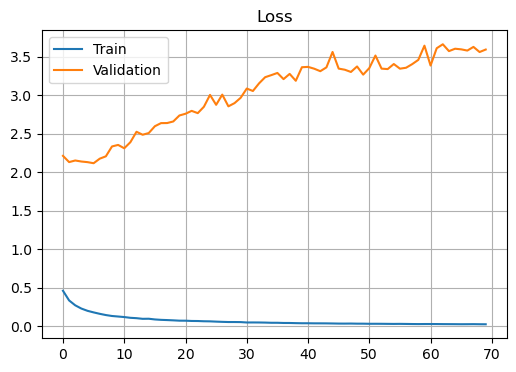

In [13]:
plt.figure(figsize=(6,4))
plt.plot(history_finetune["train_loss"], label="Train")
plt.plot(history_finetune["val_loss"], label="Validation")
plt.title("Loss")
plt.grid(True)
plt.legend()
plt.show()

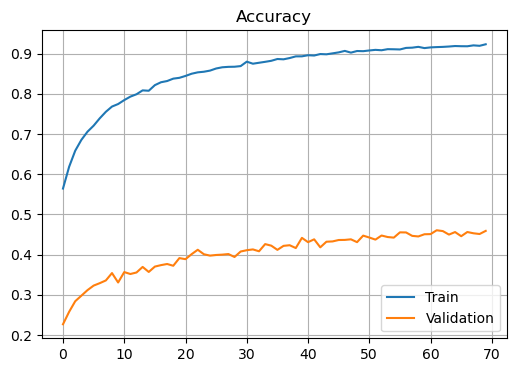

In [14]:
plt.figure(figsize=(6,4))
plt.plot(history_finetune["train_accuracy"], label="Train")
plt.plot(history_finetune["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

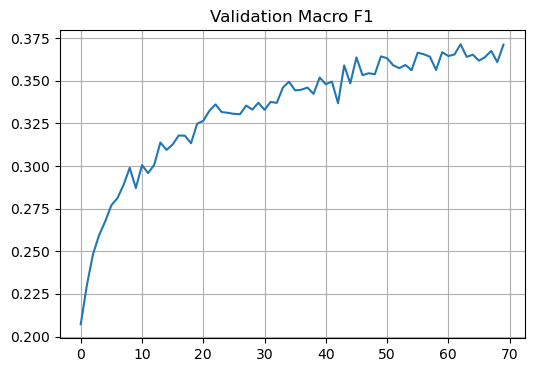

In [16]:
plt.figure(figsize=(6,4))
plt.plot(history_finetune["macro_f1"])
plt.title("Validation Macro F1")
plt.grid(True)
plt.show()

In [17]:
print(f"Best Validation Accuracy : {max(history_finetune['val_accuracy']):.4f}")
print(f"Best Validation Macro F1 : {max(history_finetune['macro_f1']):.4f}")

Best Validation Accuracy : 0.4607
Best Validation Macro F1 : 0.3714


## Model Saving

In [31]:
BUCKET_NAME = "skin-lesion-data-bucket"
MODEL_FOLDER = "models/resnet50"
s3 = boto3.client("s3")

In [32]:
os.makedirs("saved_models/resnet50", exist_ok=True)

In [33]:
checkpoint = {
    "model_name": "ResNet50",
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "class_to_idx": {
        "MEL": 0,
        "NV": 1,
        "BCC": 2,
        "AK": 3,
        "BKL": 4,
        "DF": 5,
        "VASC": 6,
        "SCC": 7,
    },
    "num_classes": NUM_CLASSES,
}

torch.save(checkpoint, "saved_models/resnet50/resnet50_checkpoint.pth")

In [35]:
class_mapping = {
    0: "MEL",
    1: "NV",
    2: "BCC",
    3: "AK",
    4: "BKL",
    5: "DF",
    6: "VASC",
    7: "SCC",
}

with open("saved_models/resnet50/class_mapping.json", "w",) as f:
    json.dump(class_mapping, f, indent=4)

In [39]:
config = {

    "model_name": "ResNet50",
    "architecture": "ResNet50",
    "version": "1.0.0",
    "created_at": datetime.now(timezone.utc).isoformat(),
    "image_size": 224,
    "num_classes": NUM_CLASSES,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "optimizer": "AdamW",
    "scheduler": "CosineAnnealingLR",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "loss": "CrossEntropyLoss",
    "label_smoothing": 0.1,
    "classes": [
        "MEL",
        "NV",
        "BCC",
        "AK",
        "BKL",
        "DF",
        "VASC",
        "SCC",
    ],
}

with open("saved_models/resnet50/model_config.json", "w",) as f:
    json.dump(config, f, indent=4)

In [40]:
history_df = pd.DataFrame(history_finetune)
history_df.to_csv("saved_models/resnet50/training_history.csv", index=False)

In [41]:
metrics = {
    "best_validation_accuracy":float(max(history_finetune["val_accuracy"])),
    "best_macro_f1":float(max(history_finetune["macro_f1"])),
    "epochs":len(history_finetune["val_accuracy"])}

with open("saved_models/resnet50/metrics.json", "w",) as f:
    json.dump(metrics, f, indent=4)

In [42]:
files_to_upload = {

    "saved_models/resnet50/resnet50_checkpoint.pth":
        f"{MODEL_FOLDER}/resnet50_checkpoint.pth",

    "saved_models/resnet50/resnet50_weights.pth":
        f"{MODEL_FOLDER}/resnet50_weights.pth",

    "saved_models/resnet50/model_config.json":
        f"{MODEL_FOLDER}/model_config.json",

    "saved_models/resnet50/class_mapping.json":
        f"{MODEL_FOLDER}/class_mapping.json",

    "saved_models/resnet50/training_history.csv":
        f"{MODEL_FOLDER}/training_history.csv",

    "saved_models/resnet50/metrics.json":
        f"{MODEL_FOLDER}/metrics.json",
}

for local_file, s3_key in files_to_upload.items():
    s3.upload_file(local_file, BUCKET_NAME, s3_key)
    print(f"Uploaded -> s3://{BUCKET_NAME}/{s3_key}")

print("All model artifacts uploaded successfully!")

Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/resnet50_checkpoint.pth
Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/resnet50_weights.pth
Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/model_config.json
Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/class_mapping.json
Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/training_history.csv
Uploaded -> s3://skin-lesion-data-bucket/models/resnet50/metrics.json
All model artifacts uploaded successfully!
